# VIX Forecasting



In [54]:
import numpy as np
import pandas as pd
import random
import optuna
from optuna.visualization import plot_pareto_front
import yahooquery as yq
from sklearn.metrics import (root_mean_squared_error,
                             balanced_accuracy_score, accuracy_score,
                             mean_squared_error)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.varmax import VARMAX
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Load & Merge Data

1. [Geopolitical Risk Index](https://www.matteoiacoviello.com/gpr.htm)
2. Volatility Index (VIX)

In [19]:
def load_and_merge_data():
    # get geopolitical risk index
    gpr_df = pd.read_stata("../data/gpr_daily.dta", columns=["date", "GPRD", "GPRD_ACT", "GPRD_THREAT"])

    # get vix
    vix = yq.Ticker("^VIX").history(interval="1d", start="1993-01-01", end="2026-01-01").reset_index()
    vix["date"] = pd.to_datetime(vix["date"])
    vix = vix \
        .drop(columns=["symbol", "open", "high", "low", "close", "volume"]) \
        .rename(columns={ "adjclose": "vix_adjclose"})

    # get spx
    spx = yq.Ticker("^SPX").history(interval="1d", start="1993-01-01", end="2026-01-01").reset_index()
    spx["date"] = pd.to_datetime(spx["date"])
    spx = spx \
        .drop(columns=["symbol", "open", "high", "low", "close", "volume"]) \
        .rename(columns={ "adjclose": "spx_adjclose" })

    # merge and drop nans
    merged = vix \
    .merge(gpr_df, on="date", how="left") \
    .merge(spx, on="date", how="left") \
    .dropna()

    # add log returns
    merged = merged.sort_values("date").reset_index(drop=True) # must sort first to diff
    merged["vix_log_return"] = np.log(merged["vix_adjclose"]).diff()
    merged["spx_log_return"] = np.log(merged["spx_adjclose"]).diff()

    merged = merged.dropna()

    return merged

In [20]:
df = load_and_merge_data()
df.head()

,date,vix_adjclose,GPRD,GPRD_ACT,GPRD_THREAT,spx_adjclose,vix_log_return,spx_log_return
1,1993-01-05,13.35,119.930664,82.456215,144.430908,434.339996,-0.000749,-0.002392
2,1993-01-06,13.37,84.319908,64.045990,106.841362,434.519989,0.001497,0.000414
3,1993-01-07,14.72,154.156281,71.479904,214.636658,430.730011,0.096194,-0.008760
4,1993-01-08,13.77,131.085571,105.958435,153.191666,429.049988,-0.066715,-0.003908
5,1993-01-11,12.86,149.133331,108.126747,180.376770,430.950012,-0.068371,0.004419


# Exploration

In [7]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch

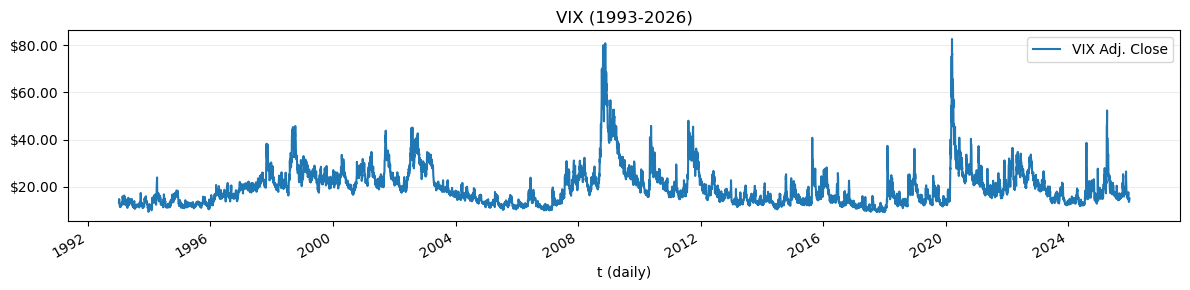

In [8]:
fig, ax = plt.subplots(figsize=(12, 3))

df[["vix_adjclose", "date"]].plot(kind="line", x="date", y="vix_adjclose", ax=ax, label="VIX Adj. Close")
# format axes
ax.yaxis.set_major_formatter("${x:,.2f}")
ax.set_xlabel("t (daily)")

# add gridlines
plt.grid(True, axis='y', color='silver', alpha=0.3, linestyle='-', linewidth=0.7)

plt.title("VIX (1993-2026)")

plt.legend()
plt.tight_layout()
plt.savefig("../figures/vix_1993_2026.png", dpi=250)
plt.show()

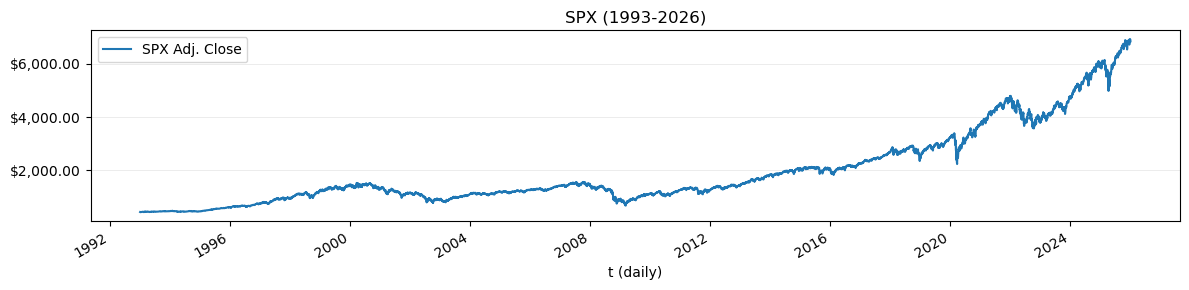

In [9]:
fig, ax = plt.subplots(figsize=(12, 3))

df[["spx_adjclose", "date"]].plot(kind="line", x="date", y="spx_adjclose", ax=ax, label="SPX Adj. Close")
ax.yaxis.set_major_formatter("${x:,.2f}")
ax.set_xlabel("t (daily)")

plt.grid(True, axis='y', color='silver', alpha=0.3, linestyle='-', linewidth=0.7)
plt.title("SPX (1993-2026)")

plt.legend()
plt.tight_layout()
plt.savefig("../figures/spx_1993_2026.png", dpi=250)
plt.show()

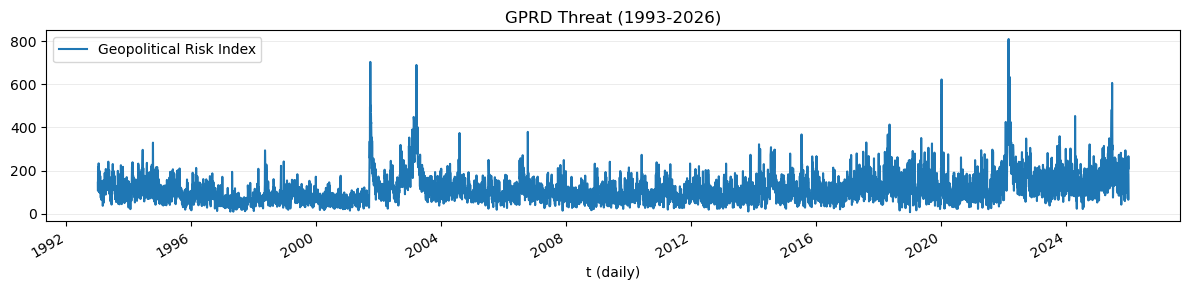

In [10]:
fig, ax = plt.subplots(figsize=(12, 3))

df[["GPRD_THREAT", "date"]].plot(kind="line", x="date", y="GPRD_THREAT", ax=ax, label="Geopolitical Risk Index")
ax.set_xlabel("t (daily)")

plt.grid(True, axis='y', color='silver', alpha=0.3, linestyle='-', linewidth=0.7)
plt.title("GPRD Threat (1993-2026)")

plt.legend()
plt.tight_layout()
plt.savefig("../figures/gprd_threat_1993_2026.png", dpi=250)
plt.show()

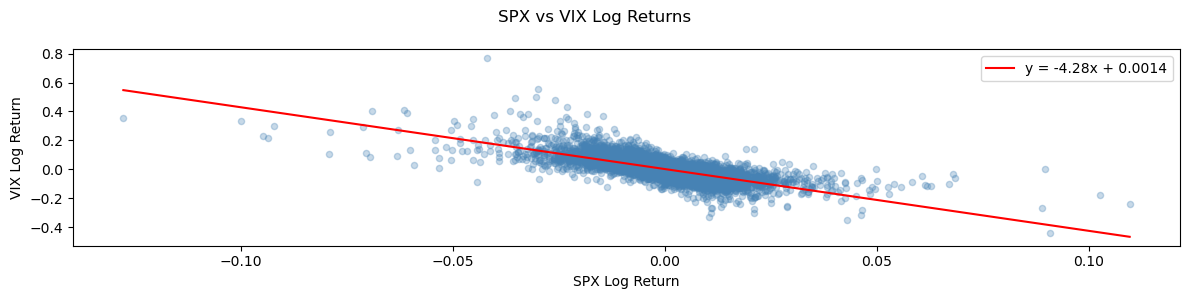

In [11]:
fig, ax = plt.subplots(figsize=(12, 3))

x = df["spx_log_return"]
y = df["vix_log_return"]

m, b = np.polyfit(x, y, 1)

df.plot(kind="scatter", x="spx_log_return", y="vix_log_return",
        ax=ax, alpha=0.3, c="steelblue")

x_sorted = np.linspace(x.min(), x.max(), 200)
ax.plot(x_sorted, m * x_sorted + b, color="red", linewidth=1.5, label=f"y = {m:.2f}x + {b:.4f}")

ax.set_ylabel("VIX Log Return")
ax.set_xlabel("SPX Log Return")

fig.suptitle("SPX vs VIX Log Returns")

plt.legend()
plt.tight_layout()
plt.savefig('../figures/spx_vix_log_return.png', dpi=250)
plt.show()

## Stationarity

If we want to forecast a time series using ARMA-type models, it needs to be stationary first.

A time series is stationary when it has:
1. a constant mean.
2. a constant variance.
3. a constant autocorrelation

If a time series is not stationary, we can apply differencing (or other transforms) to remove trends or seasonality.

$$\Delta Y_t = Y_t - Y_{t-1}$$

First we will perform the **Augmented Dickey-Fuller Test**.

Rejecting the null hypothesis $\small{(P \leq 0.05)}$ essentially is saying, "This series has a level that it always tends to drift towards." - it is stationary.

In [14]:
# test the series at 0 lags
test_statistic, p, *rest = adfuller(df["vix_adjclose"], maxlag=0)
print(f"p = {p:E}, ts = {test_statistic:.4f}")

p = 8.969665E-17, ts = -9.7317


The VIX's adjusted close is likely stationary according to `afuller`. Let's visualize it anyway:

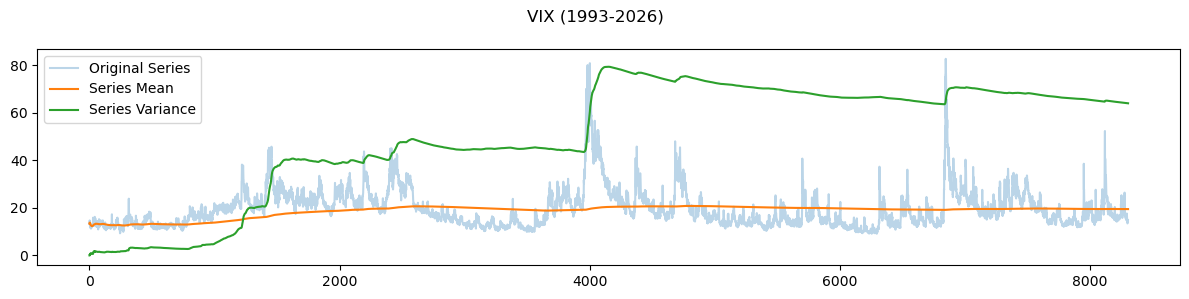

In [15]:
fig, ax = plt.subplots(figsize=(12, 3))
fig.suptitle("VIX (1993-2026)")

# get mean
cumulative_mean = np.cumsum(df["vix_adjclose"]) / np.arange(1, len(df) + 1)

# get var
cumulative_mean_sq = np.cumsum(df["vix_adjclose"] ** 2) / np.arange(1, len(df) + 1)
cumulative_variance = cumulative_mean_sq - cumulative_mean ** 2


# plot series
ax.plot(df["vix_adjclose"].tolist(), alpha=0.3, label="Original Series")
ax.plot(cumulative_mean, label="Series Mean")
ax.plot(cumulative_variance, label="Series Variance")

ax.legend()
plt.tight_layout()
plt.savefig("../figures/vix_rolling_features.png", dpi=250)
plt.show()

The series mean is mostly flat, albeit shaky. The series variance has a massive regime shift around $\small{t=2050}$; which likely violates stationarity.

Now we can try diffing (log return) to see if that yields any improvement.


_**Aside:** Another option would be splitting the data into two different regimes before and after the shift and training a model on either regime._

In [14]:
test_statistic, p, *rest = adfuller(df["vix_log_return"], maxlag=0)
print(f"p = {p:E}, ts = {test_statistic:.4f}")

p = 0.000000E+00, ts = -98.8295


The test statistic is almost 8 times greater in magnitude: a major improvement. Let's visualize:

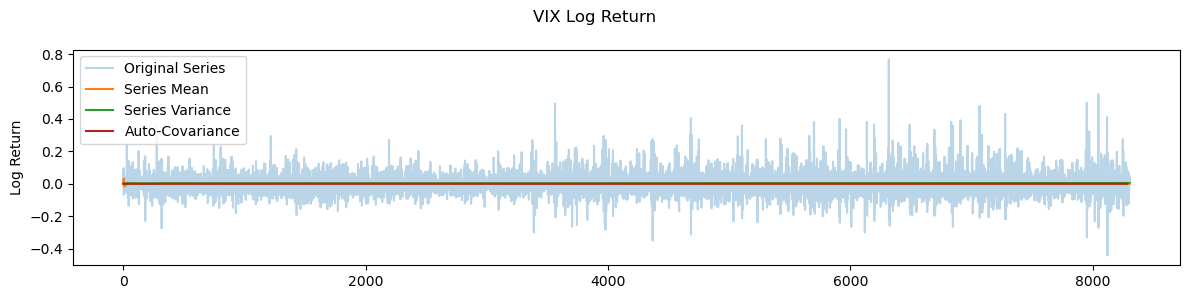

In [15]:
fig, ax = plt.subplots(figsize=(12, 3))
fig.suptitle("VIX Log Return")

# get mean
cumulative_mean = np.cumsum(df["vix_log_return"]) / np.arange(1, len(df) + 1)

# get var
cumulative_mean_sq = np.cumsum(df["vix_log_return"] ** 2) / np.arange(1, len(df) + 1)
cumulative_variance = cumulative_mean_sq - cumulative_mean ** 2

# get autocov
lag = 20
series = df["vix_log_return"].values

x      = series[lag:]      # X_t
x_lag  = series[:-lag]     # X_{t-k}

n = len(x)

cumulative_mean_x     = np.cumsum(x)     / np.arange(1, n + 1)
cumulative_mean_xlag  = np.cumsum(x_lag) / np.arange(1, n + 1)
cumulative_mean_cross = np.cumsum(x * x_lag) / np.arange(1, n + 1)

cumulative_autocov = cumulative_mean_cross - cumulative_mean_x * cumulative_mean_xlag

# plot series
ax.plot(df["vix_log_return"].tolist(), alpha=0.3, label="Original Series")
ax.plot(cumulative_mean, label="Series Mean")
ax.plot(cumulative_variance, label="Series Variance")
ax.plot(cumulative_autocov, color="firebrick", label="Auto-Covariance")
ax.set_ylabel("Log Return")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/vix_log_rolling_features.png", dpi=250)
plt.show()

Wow! Almost perfectly flat. This series is most certainly stationary. We are now able to be confident that ARMA-type models can reliably forecast the _direction_ of the series, but to ensure that magnitude forecasts are accurate, we will need the help of another test.

**Engle's Test** for Autoregressive Conditional Heteroscedasticity tells us if variance regimes are sticky.

Rejecting the null hypothesis tells us that volatility tends affect future prices and ARMA-type models will need some help forecasting swing magnitudes.

In [16]:
test_statistic, p, *rest = het_arch(df["vix_log_return"])
print(f"p = {p:E}, ts = {test_statistic:.4f}")

p = 8.851919E-92, ts = 456.4359


## Predictor Viability

Can we actually use geopolitical risk to predict the VIX's log returns? The **Granger Causailty Test** can tell us just that.

Rejecting the null hypothesis tells us that the exogenous series at a given lag is a valid predictor of the endogenous series.

In [12]:
from statsmodels.tsa.stattools import grangercausalitytests

In [13]:
x = grangercausalitytests(df[["GPRD", "vix_log_return"]], maxlag=3) # best at 1 lag


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=12.2318 , p=0.0005  , df_denom=8302, df_num=1
ssr based chi2 test:   chi2=12.2363 , p=0.0005  , df=1
likelihood ratio test: chi2=12.2273 , p=0.0005  , df=1
parameter F test:         F=12.2318 , p=0.0005  , df_denom=8302, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=9.7278  , p=0.0001  , df_denom=8299, df_num=2
ssr based chi2 test:   chi2=19.4673 , p=0.0001  , df=2
likelihood ratio test: chi2=19.4445 , p=0.0001  , df=2
parameter F test:         F=9.7278  , p=0.0001  , df_denom=8299, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=7.7983  , p=0.0000  , df_denom=8296, df_num=3
ssr based chi2 test:   chi2=23.4147 , p=0.0000  , df=3
likelihood ratio test: chi2=23.3818 , p=0.0000  , df=3
parameter F test:         F=7.7983  , p=0.0000  , df_denom=8296, df_num=3


In [14]:
x = grangercausalitytests(df[["GPRD_ACT", "vix_log_return"]], maxlag=3) # best at 1-2 lags


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.7261  , p=0.0167  , df_denom=8302, df_num=1
ssr based chi2 test:   chi2=5.7282  , p=0.0167  , df=1
likelihood ratio test: chi2=5.7262  , p=0.0167  , df=1
parameter F test:         F=5.7261  , p=0.0167  , df_denom=8302, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.4647  , p=0.0016  , df_denom=8299, df_num=2
ssr based chi2 test:   chi2=12.9372 , p=0.0016  , df=2
likelihood ratio test: chi2=12.9271 , p=0.0016  , df=2
parameter F test:         F=6.4647  , p=0.0016  , df_denom=8299, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=5.9235  , p=0.0005  , df_denom=8296, df_num=3
ssr based chi2 test:   chi2=17.7856 , p=0.0005  , df=3
likelihood ratio test: chi2=17.7666 , p=0.0005  , df=3
parameter F test:         F=5.9235  , p=0.0005  , df_denom=8296, df_num=3


In [15]:
x = grangercausalitytests(df[["GPRD_THREAT", "vix_log_return"]], maxlag=3) # best at 1 lag


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=12.5484 , p=0.0004  , df_denom=8302, df_num=1
ssr based chi2 test:   chi2=12.5529 , p=0.0004  , df=1
likelihood ratio test: chi2=12.5435 , p=0.0004  , df=1
parameter F test:         F=12.5484 , p=0.0004  , df_denom=8302, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.8569  , p=0.0011  , df_denom=8299, df_num=2
ssr based chi2 test:   chi2=13.7222 , p=0.0010  , df=2
likelihood ratio test: chi2=13.7108 , p=0.0011  , df=2
parameter F test:         F=6.8569  , p=0.0011  , df_denom=8299, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.8372  , p=0.0023  , df_denom=8296, df_num=3
ssr based chi2 test:   chi2=14.5238 , p=0.0023  , df=3
likelihood ratio test: chi2=14.5111 , p=0.0023  , df=3
parameter F test:         F=4.8372  , p=0.0023  , df_denom=8296, df_num=3


In [16]:
x = grangercausalitytests(df[["spx_log_return", "vix_log_return"]], maxlag=3) # best at 1 lag


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=13.1557 , p=0.0003  , df_denom=8302, df_num=1
ssr based chi2 test:   chi2=13.1605 , p=0.0003  , df=1
likelihood ratio test: chi2=13.1500 , p=0.0003  , df=1
parameter F test:         F=13.1557 , p=0.0003  , df_denom=8302, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=7.4843  , p=0.0006  , df_denom=8299, df_num=2
ssr based chi2 test:   chi2=14.9776 , p=0.0006  , df=2
likelihood ratio test: chi2=14.9641 , p=0.0006  , df=2
parameter F test:         F=7.4843  , p=0.0006  , df_denom=8299, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=5.3259  , p=0.0012  , df_denom=8296, df_num=3
ssr based chi2 test:   chi2=15.9913 , p=0.0011  , df=3
likelihood ratio test: chi2=15.9759 , p=0.0011  , df=3
parameter F test:         F=5.3259  , p=0.0012  , df_denom=8296, df_num=3


# Modeling

## Helper Functions

In [29]:
LAG_COLS = ["GPRD_THREAT", "GPRD_ACT", "GPRD", "spx_log_return"]
def add_lagged_exo_features(dataframe) -> pd.DataFrame:
    """shift features to their value of one period before"""
    dataframe = dataframe.copy()
    for col in LAG_COLS:
        # optimal lags determined by granger causality
        dataframe[f"{col.lower()}_shifted"] = dataframe[col].shift(1)

    return dataframe

In [72]:
def add_rolling_stats(
    frame: pd.DataFrame,
    windows: list[int],
    shifts: list[int],
    target_col: str | list[str] = "vix_log_return",
    stat: str | list[str] = "mean",
) -> pd.DataFrame:
    """
    Adds shifted rolling statistics of target columns to the DataFrame.

    For each (window, shift, stat, target_col) combination, computes a rolling
    statistic over the target column and shifts it forward, appending it as a
    new column.

    Parameters
    ----------
    frame : pd.DataFrame
        Input DataFrame.
    windows : list[int]
        Rolling window sizes (number of periods).
    shifts : list[int]
        Number of periods to shift each rolling result forward.
        Must be the same length as `windows`.
    target_col : str or list[str], optional
        Column(s) to compute rolling stats over. Either a single string applied
        to all windows, or a per-window list. Defaults to "vix_log_return".
    stat : str or list[str], optional
        Statistic to compute. Either a single string applied to all windows,
        or a per-window list. Each value must be one of "mean", "std", "min", "max".
        Defaults to "mean".

    Returns
    -------
    pd.DataFrame
        Copy of `frame` with new columns named
        `{target_col}_{window}d_{stat}_{shift}_shifted`.

    Raises
    ------
    ValueError
        If `windows`, `shifts`, `stat`, or `target_col` lists differ in length,
        or any stat value is not supported, or any target_col is missing from frame.
    """
    SUPPORTED_STATS = {"mean", "std", "min", "max"}

    if len(windows) != len(shifts):
        raise ValueError(
            f"`windows` and `shifts` must have the same length, "
            f"got {len(windows)} and {len(shifts)}."
        )

    # normalize stat to per-window list
    if isinstance(stat, str):
        if stat not in SUPPORTED_STATS:
            raise ValueError(f"Unsupported stat {stat!r}. Choose from {SUPPORTED_STATS}.")
        stats = [stat] * len(windows)
    else:
        if len(stat) != len(windows):
            raise ValueError(
                f"`stat` list must match length of `windows`, "
                f"got {len(stat)} and {len(windows)}."
            )
        unsupported = set(stat) - SUPPORTED_STATS
        if unsupported:
            raise ValueError(f"Unsupported stats {unsupported}. Choose from {SUPPORTED_STATS}.")
        stats = list(stat)

    # normalize target_col to per-window list
    if isinstance(target_col, str):
        target_cols = [target_col] * len(windows)
    else:
        if len(target_col) != len(windows):
            raise ValueError(
                f"`target_col` list must match length of `windows`, "
                f"got {len(target_col)} and {len(windows)}."
            )
        target_cols = list(target_col)

    missing = set(target_cols) - set(frame.columns)
    if missing:
        raise ValueError(f"Columns {missing} not found in frame.columns.")

    frame = frame.copy()

    for window, shift, s, col in zip(windows, shifts, stats, target_cols):
        rolled = frame[col].rolling(window=window, min_periods=window)
        series = getattr(rolled, s)()
        frame[f"{col}_{window}d_{s}_{shift}_shifted"] = series.shift(shift)

    return frame

In [44]:
def add_special_features(dataframe):
    dataframe = dataframe.copy()
    # captures "weekend effect"
    dataframe['days_since_last_trade'] = dataframe["date"].diff().dt.days.shift(1)

    return dataframe

In [45]:
def add_autoregressive_features(dataframe, p):
    """add p lags of the vix log return to the dataframe"""
    dataframe = dataframe.copy()

    for i in range(p):
        dataframe[f"vix_log_return_shift_{i + 1}"] = dataframe["vix_log_return"].shift(i + 1)

    return dataframe

In [77]:
def time_series_cv(fit_predict_fn,
                   windows=None,
                   shifts=None,
                   stats=None,
                   target_cols=None,
                   stat="mean",
                   use_ar=True,
                   plot=False,
                   plot_dir=None,
                   **kwargs):
    mse_scores = []
    rmse_scores = []
    swing_acc_scores = []
    swing_balanced_acc_scores = []
    models = []

    # set up splits
    n_splits = 4
    test_size = 242
    tscv = TimeSeriesSplit(n_splits=4, test_size=test_size)
    splits = list(tscv.split(df))

    if plot:
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, (1.5 * n_splits)))
        axes = axes.flatten()

    # train a model on each fold
    for fold, (train_idx, test_idx) in enumerate(splits):
        # build training data within the fold to limit possible data leakage
        full_idx = np.concatenate([train_idx, test_idx])
        full_df = df.iloc[full_idx].copy()

        # only toggle for non-arima models
        if use_ar:
            full_df = add_autoregressive_features(full_df, 1)

        # default windows/shifts if not provided

        _windows = windows if windows is not None else [21, 42, 365]
        _shifts  = shifts  if shifts  is not None else [1,  1,  1]
        _stats = stats     if stats   is not None else ["max", "mean", "std"]
        _target_cols = target_cols if target_cols is not None else ["vix_log_return", "vix_log_return", "vix_log_return"]

        full_df = add_rolling_stats(
            full_df,
            windows=_windows,
            shifts=_shifts,
            stat=stat,
        )
        full_df = add_special_features(full_df)

        full_df = full_df.dropna().reset_index(drop=True)

        feature_cols = [col for col in full_df.columns if col.endswith("_shifted")]
        X = full_df[feature_cols]
        X_train = X.iloc[:-test_size]
        X_test  = X.iloc[-test_size:]

        y = full_df["vix_log_return"]
        y_train = y.iloc[:-test_size]
        y_test  = y.iloc[-test_size:]

        # get predictions
        model, y_preds_raw = fit_predict_fn(X_train, y_train, X_test, y_test, **kwargs)
        y_preds = pd.Series(np.asarray(y_preds_raw), index=y_test.index)

        # get metrics
        swing_acc = (np.sign(y_preds) == np.sign(y_test)).sum() / len(y_test)
        swing_acc_scores.append(swing_acc)

        swing_balanced_acc = balanced_accuracy_score(np.sign(y_test), np.sign(y_preds))
        swing_balanced_acc_scores.append(swing_balanced_acc)

        rmse = root_mean_squared_error(y_test, y_preds)
        rmse_scores.append(rmse)

        mse = mean_squared_error(y_test, y_preds)
        mse_scores.append(mse)

        if plot:
            # plot y_test, y_preds. plot only twenty periods
            axes[fold].plot(y_test.iloc[:20], color="gray", label="test")
            axes[fold].plot(y_preds.iloc[:20], color="tomato", label="pred")
            axes[fold].scatter(x=y_preds.iloc[:20].index, y=y_preds.iloc[:20], marker="o", color="tomato")

            # add metrics
            at = AnchoredText(f"RMSE: {rmse:.3f}\nSwing Acc: {swing_acc:.2f}",
                              loc="upper left",
                              frameon=True,
                              pad=0.6,
                              prop={"fontsize": 10})

            axes[fold].add_artist(at)

            # labels
            axes[fold].set_title(f"Fold {fold + 1}", fontsize=16)
            axes[fold].set_xlabel("t")
            axes[fold].set_ylabel("log return")

            axes[fold].legend(loc="upper right")
            axes[fold].set_xticks([])

        models.append(model)

    # save plot
    if plot:
        plt.tight_layout()
        if plot_dir:
            plt.savefig(plot_dir, dpi=250)
        plt.show()


    # get mean metrics
    mean_swing_acc = np.mean(swing_acc_scores)
    mean_swing_balanced_acc = np.mean(swing_balanced_acc_scores)
    mean_rmse = np.mean(rmse_scores)
    mean_mse = np.mean(mse_scores)

    return mean_mse, mean_rmse, mean_swing_acc, mean_swing_balanced_acc, models

In [78]:
def arimax_fit_predict(X_tr, y_tr, X_te, y_te, order=(1, 0, 1), **kwargs):

    mod = SARIMAX(y_tr, exog=X_tr, order=order, trend="c", **kwargs)
    fitted = mod.fit(disp=False, method="lbfgs")
    # this model can 'honestly' predict a max of 1 period ahead without
    # using its own predictions as input.
    # we have to create a rolling window and feed in the updated
    # observed values manually.
    y_preds = []
    for t in range(len(y_te)):
        pred = fitted.forecast(steps=1, exog=X_te.iloc[[t]])
        y_preds.append(pred.iloc[0])
        # re-apply the model state with the true observation before next step
        fitted = fitted.append(y_te.iloc[[t]], exog=X_te.iloc[[t]])

    return fitted, y_preds

In [79]:
def xgb_fit_predict(X_tr, y_tr, X_te, y_te, **kwargs):
    mod = XGBRegressor(random_state=42, **kwargs)
    fitted = mod.fit(X_tr, y_tr)
    return fitted, mod.predict(X_te)

## Naive

The golden standard in trading algorithms is comparing your model results to a random guess (or what monkey would predict). Here, we use the distribution of up and down swings to make an "educated" random guess to the swing direction. If our downstream models cannot beat this, then they have failed.

In [80]:
# p(down swing)
down_proba = np.sign(df["vix_log_return"]).value_counts(normalize=True).iloc[0]

# convert to 1="up" -1="down"
y_test_full = np.sign(df["vix_log_return"])

# create random predictions
y_preds_full = [random.choices([-1, 1], weights=[down_proba, 1 - down_proba], k=1) for _ in range(len(y_test_full))]

print(f"monkey accuracy: {accuracy_score(y_test_full, y_preds_full):.3f}")
print(f"monkey balanced_accuracy: {balanced_accuracy_score(y_test_full, y_preds_full):.3f}")

monkey accuracy: 0.483
monkey balanced_accuracy: 0.322


## ARIMAX

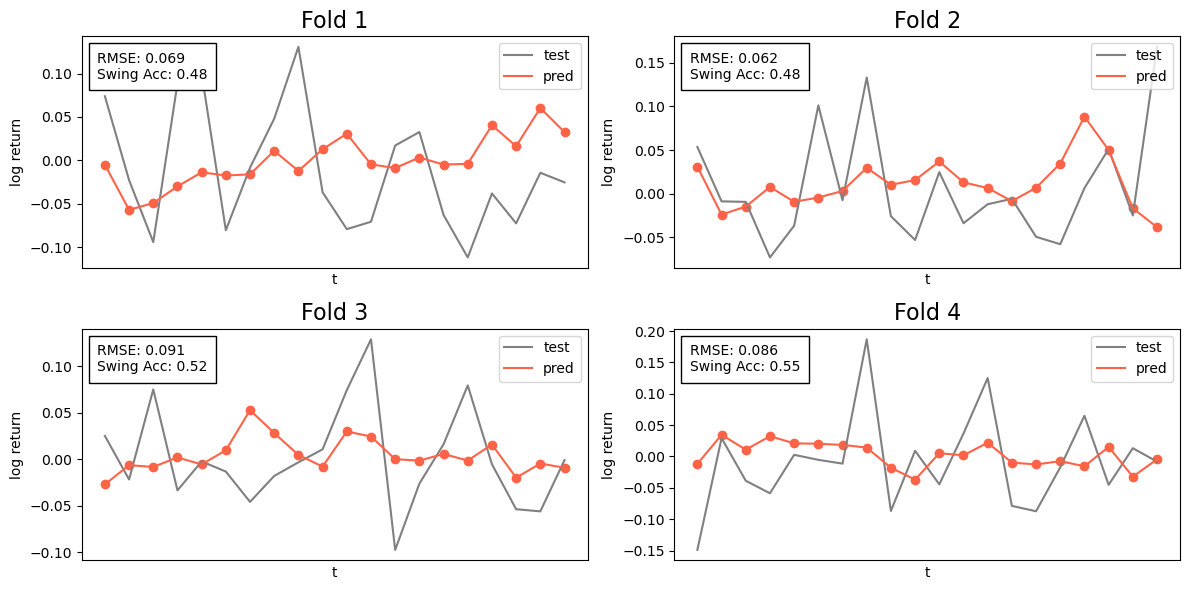

mse: 0.006085074987151177
rmse: 0.07712889862158073
accuracy: 0.5072314049586777
balanced_accuracy: 0.3817627259191445


In [81]:
(mean_mse,
 mean_rmse,
 mean_swing_acc,
 mean_balanced_swing_acc,
 models) = time_series_cv(arimax_fit_predict,
                          plot=True,
                          plot_dir="../figures/arimax.png",
                          order=(1, 1, 1))

print(f"mse: {mean_mse}")
print(f"rmse: {mean_rmse}")
print(f"accuracy: {mean_swing_acc}")
print(f"balanced_accuracy: {mean_balanced_swing_acc}")

Looks like we beat the monkeys with this model...Let's investigate the residuals to determine if there are any correlated errors. This can tell us if there is a seasonal pattern that we missed earlier.

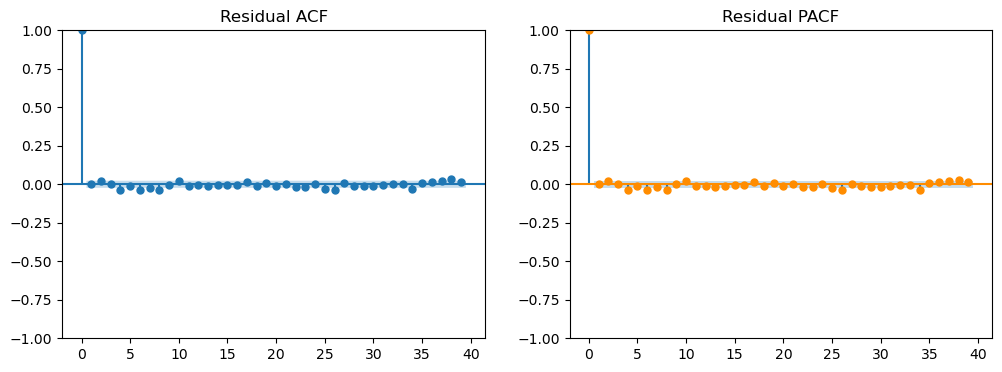

In [82]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

residuals = models[0].resid
# pacf shows similar result, thus P=1, Q=1, and s=22.
# we do not need to difference so D=0

fig, axes = plt.subplots(figsize=(12, 4), ncols=2, )
axes = axes.flatten()
plot_acf(residuals, title="Residual ACF", ax=axes[0])
plot_pacf(residuals, title="Residual PACF", ax=axes[1], color="darkorange")
plt.show()

We don't observe any statistically significant lags of forecast errors. No seasonality.

### Tuning

In [63]:
def objective_arimax(trial: optuna.Trial, **kwargs):
    # --- tune number of rolling windows ---
    n_windows = trial.suggest_int("n_windows", 1, 5)

    # --- tune each window size and its corresponding shift ---
    windows = []
    shifts = []
    for i in range(n_windows):
        window = trial.suggest_int(f"window_{i}", 5, 365, log=True)
        shift  = trial.suggest_int(f"shift_{i}",  1, 22) # up to one trading month
        windows.append(window)
        shifts.append(shift)

    # --- tune the rolling statistic ---
    stat = trial.suggest_categorical("stat", ["mean", "std", "min", "max"])

    # --- run CV and return the metric to minimize ---
    (mean_mse,
     mean_rmse,
     mean_swing_acc,
     mean_swing_balanced_acc, _) = time_series_cv(
        fit_predict_fn=arimax_fit_predict,
        windows=windows,
        shifts=shifts,
        stat=stat,
        **kwargs,
    )

    # store extra metrics as user attributes for later inspection
    trial.set_user_attr("rmse",               mean_rmse)
    trial.set_user_attr("swing_acc",          mean_swing_acc)
    trial.set_user_attr("swing_balanced_acc", mean_swing_balanced_acc)

    return mean_swing_acc, mean_mse

In [63]:
study_sarimax = optuna.create_study(
    directions=["maximize", "minimize"], # max swing acc, min mse
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="sarimax_cv",
)
study_sarimax.optimize(objective_arimax, n_trials=50, show_progress_bar=True)

[I 2026-06-04 18:05:57,303] A new study created in memory with name: sarimax_cv
  2%|▏         | 1/50 [00:48<39:54, 48.86s/it]

[I 2026-06-04 18:06:46,160] Trial 0 finished with values: [0.5289256198347108, 0.005282919365345789] and parameters: {'n_windows': 2, 'window_0': 294, 'shift_0': 17, 'window_1': 63, 'shift_1': 4, 'stat': 'min'}.


  2%|▏         | 1/50 [01:16<1:02:40, 76.74s/it]

KeyboardInterrupt



[W 2026-06-04 18:07:13,920] Trial 1 failed with parameters: {'n_windows': 4, 'window_0': 5, 'shift_0': 22, 'window_1': 175, 'shift_1': 5, 'window_2': 10, 'shift_2': 5, 'window_3': 17, 'shift_3': 12, 'stat': 'min'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\miniforge3\envs\machine-learning\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Austin Muelrath\AppData\Local\Temp\ipykernel_14736\1150071556.py", line 21, in objective_arimax
    mean_swing_balanced_acc, _) = time_series_cv(
                                  ^^^^^^^^^^^^^^^
  File "C:\Users\Austin Muelrath\AppData\Local\Temp\ipykernel_14736\3343919820.py", line 59, in time_series_cv
    model, y_preds_raw = fit_predict_fn(X_train, y_train, X_test, y_test, **kwargs)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Austin 

KeyboardInterrupt: 

In [87]:
fig = plot_pareto_front(study_sarimax, target_names=["swing_accuracy", "rmse"])
fig.show()

In [88]:
BEST_SARIMAX_FEATURES = []

## XGBoost

We format our data similarly to that of the autoregressive models (excluding the MA features). To do this, we manually `add_autoregressive_features` via `use_ar=True`. `statsmodels` SARIMAX does this for us automatically.

ERROR! Session/line number was not unique in database. History logging moved to new session 1164


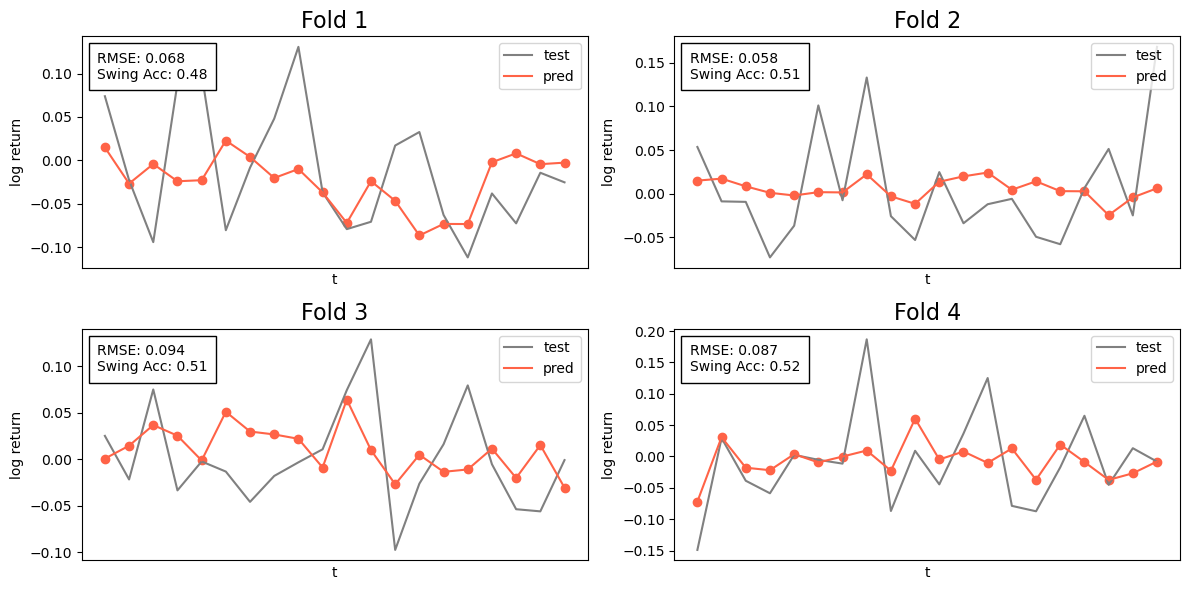

mse: 0.006087095824163032
rmse: 0.07665342646163664
accuracy: 0.506198347107438
balanced_accuracy: 0.38495813267473006


In [64]:
(mean_mse,
mean_rmse,
mean_swing_acc,
mean_balanced_swing_acc,
models) = time_series_cv(xgb_fit_predict,
               use_ar=True,
               plot=True,
               plot_dir="../figures/xgboost_bench.png")

print(f"mse: {mean_mse}")
print(f"rmse: {mean_rmse}")
print(f"accuracy: {mean_swing_acc}")
print(f"balanced_accuracy: {mean_balanced_swing_acc}")

### Tuning

Since XGBoost is readily fine-tunable, we will first determine the best rolling features and then we will tune hyperparameters.

In [85]:
def objective_xgboost_features(trial: optuna.Trial, **kwargs):
    available_cols = ["vix_log_return", "spx_log_return", "gprd_shifted", "gprd_threat_shifted"]
    n_windows = trial.suggest_int("n_windows", 1, 20)

    windows = []
    shifts = []
    stats = []
    target_cols = []
    for i in range(n_windows):
        window     = trial.suggest_int(f"window_{i}",     5, 365)
        shift      = trial.suggest_int(f"shift_{i}",      1, 22)
        stat       = trial.suggest_categorical(f"stat_{i}",       ["mean", "std", "min", "max"])
        target_col = trial.suggest_categorical(f"target_col_{i}", available_cols)
        windows.append(window)
        shifts.append(shift)
        stats.append(stat)
        target_cols.append(target_col)

    (mean_mse,
     mean_rmse,
     mean_swing_acc,
     mean_swing_balanced_acc, _) = time_series_cv(
        fit_predict_fn=xgb_fit_predict,
        windows=windows,
        shifts=shifts,
        stat=stats,
        target_col=target_cols,
        **kwargs,
    )

    trial.set_user_attr("rmse",               mean_rmse)
    trial.set_user_attr("swing_acc",          mean_swing_acc)
    trial.set_user_attr("swing_balanced_acc", mean_swing_balanced_acc)

    return mean_swing_acc, mean_mse

In [86]:
study_xgboost_features = optuna.create_study(
    directions=["maximize", "minimize"], # max swing acc, min mse
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="xgb_cv",
)
study_xgboost_features.optimize(objective_xgboost_features, n_trials=500, show_progress_bar=True)

[I 2026-06-04 18:22:47,136] A new study created in memory with name: xgb_cv
  0%|          | 1/500 [00:00<02:34,  3.22it/s]

[I 2026-06-04 18:22:47,446] Trial 0 finished with values: [0.4989669421487603, 0.007656235826494202] and parameters: {'n_windows': 8, 'window_0': 348, 'shift_0': 17, 'stat_0': 'mean', 'target_col_0': 'vix_log_return', 'window_1': 355, 'shift_1': 19, 'stat_1': 'max', 'target_col_1': 'gprd_threat_shifted', 'window_2': 55, 'shift_2': 7, 'stat_2': 'min', 'target_col_2': 'gprd_threat_shifted', 'window_3': 66, 'shift_3': 2, 'stat_3': 'std', 'target_col_3': 'spx_log_return', 'window_4': 183, 'shift_4': 1, 'stat_4': 'mean', 'target_col_4': 'gprd_threat_shifted', 'window_5': 284, 'shift_5': 21, 'stat_5': 'min', 'target_col_5': 'gprd_threat_shifted', 'window_6': 102, 'shift_6': 19, 'stat_6': 'min', 'target_col_6': 'gprd_shifted', 'window_7': 76, 'shift_7': 1, 'stat_7': 'mean', 'target_col_7': 'gprd_threat_shifted'}.


  0%|          | 2/500 [00:00<02:52,  2.88it/s]

[I 2026-06-04 18:22:47,820] Trial 1 finished with values: [0.509297520661157, 0.00645386525437311] and parameters: {'n_windows': 13, 'window_0': 124, 'shift_0': 2, 'stat_0': 'min', 'target_col_0': 'vix_log_return', 'window_1': 279, 'shift_1': 13, 'stat_1': 'mean', 'target_col_1': 'gprd_threat_shifted', 'window_2': 118, 'shift_2': 12, 'stat_2': 'mean', 'target_col_2': 'gprd_shifted', 'window_3': 340, 'shift_3': 18, 'stat_3': 'std', 'target_col_3': 'gprd_threat_shifted', 'window_4': 119, 'shift_4': 3, 'stat_4': 'max', 'target_col_4': 'spx_log_return', 'window_5': 48, 'shift_5': 8, 'stat_5': 'mean', 'target_col_5': 'spx_log_return', 'window_6': 184, 'shift_6': 7, 'stat_6': 'min', 'target_col_6': 'gprd_shifted', 'window_7': 57, 'shift_7': 11, 'stat_7': 'mean', 'target_col_7': 'spx_log_return', 'window_8': 233, 'shift_8': 12, 'stat_8': 'std', 'target_col_8': 'gprd_shifted', 'window_9': 189, 'shift_9': 5, 'stat_9': 'min', 'target_col_9': 'vix_log_return', 'window_10': 338, 'shift_10': 20, 's

  1%|          | 3/500 [00:01<03:11,  2.59it/s]

...

[I 2026-06-04 18:25:39,221] Trial 497 finished with values: [0.5227272727272727, 0.006640032737918267] and parameters: {'n_windows': 16, 'window_0': 273, 'shift_0': 8, 'stat_0': 'min', 'target_col_0': 'vix_log_return', 'window_1': 142, 'shift_1': 16, 'stat_1': 'mean', 'target_col_1': 'gprd_threat_shifted', 'window_2': 341, 'shift_2': 8, 'stat_2': 'min', 'target_col_2': 'spx_log_return', 'window_3': 365, 'shift_3': 10, 'stat_3': 'mean', 'target_col_3': 'spx_log_return', 'window_4': 230, 'shift_4': 12, 'stat_4': 'std', 'target_col_4': 'gprd_shifted', 'window_5': 117, 'shift_5': 4, 'stat_5': 'min', 'target_col_5': 'spx_log_return', 'window_6': 331, 'shift_6': 5, 'stat_6': 'std', 'target_col_6': 'vix_log_return', 'window_7': 42, 'shift_7': 18, 'stat_7': 'std', 'target_col_7': 'spx_log_return', 'window_8': 259, 'shift_8': 9, 'stat_8': 'min', 'target_col_8': 'spx_log_return', 'window_9': 96, 'shift_9': 4, 'stat_9': 'max', 'target_col_9': 'gprd_threat_shifted', 'window_10': 155, 'shift_10': 3

100%|█████████▉| 499/500 [02:52<00:00,  2.00it/s]

[I 2026-06-04 18:25:39,699] Trial 498 finished with values: [0.5051652892561983, 0.00746466192830397] and parameters: {'n_windows': 11, 'window_0': 93, 'shift_0': 21, 'stat_0': 'std', 'target_col_0': 'vix_log_return', 'window_1': 294, 'shift_1': 20, 'stat_1': 'max', 'target_col_1': 'spx_log_return', 'window_2': 277, 'shift_2': 20, 'stat_2': 'max', 'target_col_2': 'gprd_shifted', 'window_3': 184, 'shift_3': 20, 'stat_3': 'std', 'target_col_3': 'vix_log_return', 'window_4': 162, 'shift_4': 7, 'stat_4': 'max', 'target_col_4': 'vix_log_return', 'window_5': 55, 'shift_5': 17, 'stat_5': 'std', 'target_col_5': 'gprd_shifted', 'window_6': 237, 'shift_6': 20, 'stat_6': 'min', 'target_col_6': 'spx_log_return', 'window_7': 291, 'shift_7': 5, 'stat_7': 'min', 'target_col_7': 'gprd_shifted', 'window_8': 212, 'shift_8': 3, 'stat_8': 'max', 'target_col_8': 'gprd_threat_shifted', 'window_9': 291, 'shift_9': 20, 'stat_9': 'std', 'target_col_9': 'spx_log_return', 'window_10': 120, 'shift_10': 19, 'stat_

100%|██████████| 500/500 [02:52<00:00,  2.89it/s]

[I 2026-06-04 18:25:39,942] Trial 499 finished with values: [0.4958677685950413, 0.005644743718321112] and parameters: {'n_windows': 2, 'window_0': 151, 'shift_0': 10, 'stat_0': 'min', 'target_col_0': 'vix_log_return', 'window_1': 53, 'shift_1': 5, 'stat_1': 'min', 'target_col_1': 'gprd_shifted'}.


In [87]:
fig = plot_pareto_front(study_xgboost_features, target_names=["swing_accuracy", "mse"])
fig.show()

# best trial looks like: 344 (0.57, 0.0053)

In [92]:
# reconstruct best feature parameters
best = study_xgboost_features.trials[344].params
n = best["n_windows"]
best_xgb_windows     = [best[f"window_{i}"]     for i in range(n)]
best_xgb_shifts      = [best[f"shift_{i}"]      for i in range(n)]
best_xgb_stats       = [best[f"stat_{i}"]       for i in range(n)]
best_xgb_target_cols = [best[f"target_col_{i}"] for i in range(n)]

In [93]:
def objective_xgb(trial):
    # Tree structure
    max_depth = trial.suggest_int("max_depth", 3, 12)
    min_child_weight = trial.suggest_float("min_child_weight", 1, 20, log=True)
    min_split_loss = trial.suggest_float("min_split_loss", 1e-8, 5.0, log=True)  # gamma

    # Learning rate & boosting rounds
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    n_estimators = trial.suggest_int("n_estimators", 100, 500, step=50)

    # Sampling
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.3, 1.0)
    colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.5, 1.0)

    # Regularization
    reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True)  # L1
    reg_lambda = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)  # L2

    try:
        (mean_mse,
         mean_rmse,
         mean_swing_acc,
         mean_balanced_swing_acc,
         models) = time_series_cv(xgb_fit_predict,
                                  use_ar=True,
                                  windows=best_xgb_windows,
                                  shifts=best_xgb_shifts,
                                  stats=best_xgb_stats,
                                  target_cols=best_xgb_target_cols,
                                  device="cuda:0",
                                  tree_method="hist",
                                  max_depth=max_depth,
                                  min_child_weight=min_child_weight,
                                  min_split_loss=min_split_loss,
                                  learning_rate=learning_rate,
                                  n_estimators=n_estimators,
                                  subsample=subsample,
                                  colsample_bytree=colsample_bytree,
                                  colsample_bylevel=colsample_bylevel,
                                  reg_alpha=reg_alpha,
                                  reg_lambda=reg_lambda)

        return mean_swing_acc, mean_rmse

    except (ValueError, np.linalg.LinAlgError) as e:
        raise optuna.TrialPruned() from e

In [94]:
study_xgb = optuna.create_study(
    directions=["maximize", "minimize"], # max swing acc, min mse
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="xgb_cv",
)
study_xgb.optimize(objective_xgb, n_trials=300, show_progress_bar=True)

[I 2026-06-04 18:26:46,528] A new study created in memory with name: xgb_cv
  0%|          | 1/300 [00:00<04:52,  1.02it/s]

[I 2026-06-04 18:26:47,507] Trial 0 finished with values: [0.5165289256198347, 0.0718820244673469] and parameters: {'max_depth': 6, 'min_child_weight': 17.25471657328035, 'min_split_loss': 0.023312741235833014, 'learning_rate': 0.07661100707771368, 'n_estimators': 150, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.3406585285177396, 'colsample_bylevel': 0.9330880728874675, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682}.


  1%|          | 2/300 [00:01<03:33,  1.40it/s]

[I 2026-06-04 18:26:48,037] Trial 1 finished with values: [0.5072314049586777, 0.07204119380329839] and parameters: {'max_depth': 3, 'min_child_weight': 18.276027831785726, 'min_split_loss': 0.17433860342268107, 'learning_rate': 0.020589728197687916, 'n_estimators': 150, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.5129695700716763, 'colsample_bylevel': 0.762378215816119, 'reg_alpha': 7.71800699380605e-05, 'reg_lambda': 4.17890272377219e-06}.


  1%|          | 3/300 [00:06<13:44,  2.78s/it]

...

[I 2026-06-04 18:32:30,142] Trial 151 finished with values: [0.5206611570247934, 0.07191211934279981] and parameters: {'max_depth': 3, 'min_child_weight': 7.920731126848125, 'min_split_loss': 4.818168649931565e-08, 'learning_rate': 0.018492820930555993, 'n_estimators': 100, 'subsample': 0.7604798198012659, 'colsample_bytree': 0.7994342158280567, 'colsample_bylevel': 0.5634175411268085, 'reg_alpha': 3.878824260489403e-08, 'reg_lambda': 0.018555052654361998}.


 51%|█████     | 152/300 [05:45<05:35,  2.27s/it]
Exception ignored in: <function tqdm.__del__ at 0x000001AEFDE66700>
Traceback (most recent call last):
  File "C:\miniforge3\envs\machine-learning\Lib\site-packages\tqdm\std.py", line 1148, in __del__


[W 2026-06-04 18:32:31,551] Trial 152 failed with parameters: {'max_depth': 3, 'min_child_weight': 9.811694067309508, 'min_split_loss': 3.3672537857355726e-08, 'learning_rate': 0.014341281236063149, 'n_estimators': 250, 'subsample': 0.7895429192260893, 'colsample_bytree': 0.81480244283039, 'colsample_bylevel': 0.6068617569215424, 'reg_alpha': 0.18186028285957798, 'reg_lambda': 0.00023414833182469621} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\miniforge3\envs\machine-learning\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Austin Muelrath\AppData\Local\Temp\ipykernel_14736\605540609.py", line 25, in objective_xgb
    models) = time_series_cv(xgb_fit_predict,
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Austin Muelrath\AppData\Local\Temp\ipykernel_14736\531250368.py", line 64, in time_series_cv
    model, y_pr

    self.close()
  File "C:\miniforge3\envs\machine-learning\Lib\site-packages\tqdm\std.py", line 1265, in close
    def close(self):

KeyboardInterrupt: 


KeyboardInterrupt: 

In [126]:
fig = plot_pareto_front(study_xgb, target_names=["swing_accuracy", "rmse"])
fig.show()

In [127]:
BEST_XGB_PARAMS = study_xgb.trials[269].params

# Backtesting

In [99]:
from backtesting import Backtest, Strategy

In [100]:
class VixPredStrategy(Strategy):
    vix_rise_threshold = 0.015   # above this -> expect spy to go down
    vix_fall_threshold = -0.015  # below this -> expect spy to go up

    def init(self):
        # declare indicators
        self.vix_pred = self.I(func=lambda: self.data.PredVixLogReturn,
                               name="PredVixLogReturn")

    def next(self):
        pred = self.vix_pred[-1] # today's row

        # if we aren't already holding stock
        if not self.position:
            # we predict fear falls, spy should to go up tomorrow
            if pred < self.vix_fall_threshold:
                self.buy()
        else:
            # we predict fear rises, spy should go down tomorrow
            if pred > self.vix_rise_threshold:
                self.position.close()

In [101]:
def fetch_spx(start, end):
    df = yq.Ticker("SPY").history(start=start, end=end).reset_index().drop(columns="symbol")
    df = df.rename(columns={
        "open": "Open", "high": "High",
        "low": "Low",   "close": "Close",
        "volume": "Volume"
    })
    df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)
    df = df.set_index("date")
    return df

spx_test_df = fetch_spx("2023-01-01", "2024-01-01")
spx_val_df  = fetch_spx("2024-01-01", "2025-01-01")

In [102]:
def attach_preds(spx_df, preds, df):
    dates = pd.to_datetime(df["date"].values).tz_localize(None)
    pred_series = pd.Series(preds.values, index=dates).shift(1)
    spx = spx_df[spx_df.index.isin(pred_series.index)].copy()
    spx["PredVixLogReturn"] = pred_series.reindex(spx.index)
    return spx.dropna()

## ARIMAX

### Train Final Model

In [103]:
# --- reconstruct best rolling params from study ---
best = study.best_params
n = best["n_windows"]
best_windows = [best[f"window_{i}"] for i in range(n)]
best_shifts  = [best[f"shift_{i}"]  for i in range(n)]
best_stat    = best["stat"]

# --- build full_df with tuned rolling stats ---
full_df = add_rolling_stats(
    df,
    windows=best_windows,
    shifts=best_shifts,
    stat=best_stat,
)

full_df = add_special_features(full_df, features=BEST_SARIMAX_FEATURES)
full_df = add_lagged_exo_features(full_df)
full_df = add_special_features(full_df)
full_df = full_df.dropna().reset_index(drop=True)

feature_cols = [col for col in full_df.columns if col.endswith("_shifted")]

train_df = full_df[full_df["date"] < "2023-01-01"]
X_train = train_df[feature_cols]
y_train = train_df["vix_log_return"]

test_df = full_df[(full_df["date"] >= "2023-01-01") & (full_df["date"] < "2024-01-01")]
X_test = test_df[feature_cols]
y_test = test_df["vix_log_return"]

val_df = full_df[full_df["date"] >= "2024-01-01"]
X_val = val_df[feature_cols]
y_val = val_df["vix_log_return"]

In [104]:
sarimax = SARIMAX(y_train, exog=X_train, order=(1, 1, 1), trend="c").fit(disp=False, method="lbfgs")

def walk_forward_predict(model, y, X):
    """Returns a Series of one-step-ahead predictions, aligned to y's index."""
    preds = []
    for t in range(len(y)):
        pred = model.forecast(steps=1, exog=X.iloc[[t]])
        preds.append(pred.iloc[0])
        model = model.append(y.iloc[[t]], exog=X.iloc[[t]])
    return pd.Series(preds, index=y.index), model

y_preds_test, sarimax_updated = walk_forward_predict(sarimax, y_test, X_test)
y_preds_val,  _               = walk_forward_predict(sarimax_updated, y_val, X_val)

In [105]:
spx_test = attach_preds(spx_test_df, y_preds_test, test_df)
spx_val  = attach_preds(spx_val_df,  y_preds_val,  val_df)

### Backtest

In [106]:
bt_test = Backtest(spx_test, VixPredStrategy, cash=100_000, commission=0, exclusive_orders=True)

opt, heatmap = bt_test.optimize(
    vix_rise_threshold=[0.005, 0.01, 0.02, 0.03, 0.04, 0.05],
    vix_fall_threshold=[-0.05, -0.04, -0.03, -0.02, -0.01, -0.05],
    maximize="Sharpe Ratio",
    constraint=lambda p: p.vix_fall_threshold < p.vix_rise_threshold,
    return_heatmap=True,
)

best_rise = opt._strategy.vix_rise_threshold
best_fall = opt._strategy.vix_fall_threshold

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]
                                                      
Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]
                                                      

                                                      
Backtest.optimize:   3%|▎         | 1/36 [00:00<00:03,  8.84it/s]

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]
                                                      

                                                      
Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]
                                                      
Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]


Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]



Backtest.optimize:   6%|▌         | 2/36 [00:00<00:05,  6.64it/s]A

                                                      
                               

In [107]:
bt_val = Backtest(spx_val, VixPredStrategy, cash=100_000, commission=0, exclusive_orders=True)

val_results = bt_val.run(
    vix_rise_threshold=best_rise,
    vix_fall_threshold=best_fall,
)

In [108]:
metrics = ["Buy & Hold Return [%]", "Return [%]", "Max. Drawdown [%]", "Sharpe Ratio", "# Trades"]
print("\n── Test results ──")
print(opt[metrics])
print("\n── Val results ──")
print(val_results[metrics])


── Test results ──
Buy & Hold Return [%]    23.856052
Return [%]               13.063024
Max. Drawdown [%]        -5.973308
Sharpe Ratio              1.227178
# Trades                        32
dtype: object

── Val results ──
Buy & Hold Return [%]    25.019733
Return [%]                6.237711
Max. Drawdown [%]        -5.144054
Sharpe Ratio                0.7586
# Trades                        27
dtype: object


In [109]:
bt_val.plot(plot_equity=False, plot_volume=False, plot_return=False);

In [ ]:
del bt_val

## XGBoost

### Train Final Model

In [128]:
# --- reconstruct best rolling params from study ---

# --- build full_df with tuned rolling stats ---
full_df = add_rolling_stats(
    df,
    windows=best_xgb_windows,
    shifts=best_xgb_shifts,
    stat=best_xgb_stats,
    target_col=best_xgb_target_cols,
)

full_df = add_special_features(full_df)
full_df = add_lagged_exo_features(full_df)
full_df = add_special_features(full_df)
full_df = add_autoregressive_features(full_df, 1)
full_df = full_df.dropna().reset_index(drop=True)

feature_cols = [col for col in full_df.columns if col.endswith("_shifted")]

train_df = full_df[full_df["date"] < "2023-01-01"]
X_train = train_df[feature_cols]
y_train = train_df["vix_log_return"]

test_df = full_df[(full_df["date"] >= "2023-01-01") & (full_df["date"] < "2024-01-01")]
X_test = test_df[feature_cols]
y_test = test_df["vix_log_return"]

val_df = full_df[full_df["date"] >= "2024-01-01"]
X_val = val_df[feature_cols]
y_val = val_df["vix_log_return"]

In [129]:
xgboost = XGBRegressor(random_state=42, **BEST_XGB_PARAMS)
xgboost.fit(X_train, y_train)

y_preds_test = pd.Series(xgboost.predict(X_test), index=y_test.index)
y_preds_val = pd.Series(xgboost.predict(X_val), index=y_val.index)

In [130]:
spx_test = attach_preds(spx_test_df, y_preds_test, test_df)
spx_val  = attach_preds(spx_val_df,  y_preds_val,  val_df)

### Backtest

In [131]:
bt_test = Backtest(spx_test, VixPredStrategy, cash=100_000, commission=0, exclusive_orders=True)

opt, heatmap = bt_test.optimize(
    vix_rise_threshold=[0.005, 0.01, 0.02, 0.03, 0.04, 0.05],
    vix_fall_threshold=[-0.05, -0.04, -0.03, -0.02, -0.01, -0.05, -0.06, -0.07, -0.08],
    maximize="Sharpe Ratio",
    constraint=lambda p: p.vix_fall_threshold < p.vix_rise_threshold,
    return_heatmap=True,
)

best_rise = opt._strategy.vix_rise_threshold
best_fall = opt._strategy.vix_fall_threshold

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]
                                                      
Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]
                                                      
Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]
                                                      
Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]
                                                      

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]

                                                      
                                                      

Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]




Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]



Backtest.run:   0%|          | 0/248 [00:00<?, ?bar/s]


Backtest.optimize:   2%|▏         | 1/54 [00:00<00:16,  3.14it/s]

                                                      




                                                      



                                  

In [132]:
bt_val = Backtest(spx_val, VixPredStrategy, cash=100_000, commission=0, exclusive_orders=True)

val_results = bt_val.run(
    vix_rise_threshold=best_rise,
    vix_fall_threshold=best_fall,
)

In [133]:
metrics = ["Buy & Hold Return [%]", "Return [%]", "Max. Drawdown [%]", "Sharpe Ratio", "# Trades"]
print("\n── Test results ──")
print(opt[metrics])
print("\n── Val results ──")
print(val_results[metrics])


── Test results ──
Buy & Hold Return [%]    23.856052
Return [%]               12.794399
Max. Drawdown [%]        -0.944326
Sharpe Ratio              2.716906
# Trades                         1
dtype: object

── Val results ──
Buy & Hold Return [%]    25.019733
Return [%]                0.670273
Max. Drawdown [%]         -4.12621
Sharpe Ratio              0.162494
# Trades                         3
dtype: object


In [134]:
bt_val.plot(plot_equity=False, plot_volume=False, plot_return=False);